# C05 · Trolley problems: is a 1-7 rating a number?

| | |
|---|---|
| **Difficulty** | ★★★☆☆ |
| **Time** | 3-4 hours |
| **Data** | Cushman, Young & Hauser (2006): 9,930 permissibility ratings (1-7) of trolley-style dilemmas by 331 people |
| **Skills** | Designing a posterior predictive check for discrete data · ordered-logistic regression · the `ordered` transform and initial values · interpreting on the outcome scale · varying intercepts with 100+ groups · LOO · judging when a "wrong" model still gives the right answer |

## The brief

A survey-research team ran a moral-judgement study. Each participant read 30 short stories
in which someone's action leads to a death, and rated how **morally permissible** the action
was from 1 (absolutely not) to 7 (absolutely). The stories vary three features:

- **action** - the harm comes from doing something rather than from failing to act;
- **intention** - the death is a means to the agent's goal, not a side effect;
- **contact** - the agent physically touches the victim (in this coding contact stories are
  *not* also flagged as action).

The team analyses the ratings the way most survey teams do: ordinary linear regression on
the numbers 1-7. A reviewer has told them that this is indefensible for Likert-type data.
The team lead is unconvinced: *"Everyone does it and the effects are huge. Show me one
conclusion that would change."*

Your job is to find out who is right - and to be honest about it in both directions.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", cut_first=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.special import expit, logit

from pymc_challenges import Hints, data

RANDOM_SEED = 2006
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C05")
h.tasks()

**C05 - Trolley problems: is a 1-7 rating a number?**

- `task0` - Look at the outcome (2 hints)
- `task1` - The team's linear model and a check that exposes it (3 hints, 2 check(s))
- `task2` - Ordered logistic, cutpoints only (3 hints, 2 check(s))
- `task3` - Ordinal regression with predictors (3 hints, 4 check(s))
- `task4` - Predictions on the response scale (3 hints, 3 check(s))
- `task5` - Participant and story effects (3 hints, 2 check(s))
- `task6` - Does the metric shortcut change a conclusion? (3 hints, 4 check(s))

## The data

One row per rating. `response` is the 1-7 rating, `id` the participant, `story` one of 12
story settings (a boat, a burning building, a switch...), and `action`, `intention`,
`contact` the 0/1 features of the version of the story that was shown. `age`, `male` and
`edu` describe the participant.

In [2]:
data.describe("trolley")
trolley = data.load("trolley")
trolley.head()

trolley: 9930 ordinal (1-7) permissibility ratings from 331 participants.
  source: Cushman, Young & Hauser (2006) moral-judgement experiment, via `rethinking`.
  url:    https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Trolley.csv


,case,response,order,id,age,male,edu,action,intention,contact,story,action2
0,cfaqu,4,2,96;434,14,0,Middle School,0,0,1,aqu,1
1,cfbur,3,31,96;434,14,0,Middle School,0,0,1,bur,1
2,cfrub,4,16,96;434,14,0,Middle School,0,0,1,rub,1
3,cibox,3,32,96;434,14,0,Middle School,0,1,1,box,1
4,cibur,3,4,96;434,14,0,Middle School,0,1,1,bur,1


Only six combinations of the three features occur in the experiment. We will call them
**scenarios** and refer to them by these names throughout:

In [3]:
scenarios = pd.DataFrame(
    {"action": [0, 1, 0, 0, 1, 0], "intention": [0, 0, 0, 1, 1, 1], "contact": [0, 0, 1, 0, 0, 1]},
    index=pd.Index(
        ["none", "action", "contact", "intention", "action+intention", "contact+intention"],
        name="scenario",
    ),
)
key = ["action", "intention", "contact"]
trolley["scenario"] = pd.Categorical(
    trolley[key].merge(scenarios.reset_index(), on=key, how="left")["scenario"],
    categories=scenarios.index,
)
scenarios.assign(n=trolley.scenario.value_counts().reindex(scenarios.index))

,action,intention,contact,n
scenario,,,,
none,0,0,0,1655
action,1,0,0,2648
contact,0,0,1,993
intention,0,1,0,1986
action+intention,1,1,0,1655
contact+intention,0,1,1,993


## Task 0 · Look at the outcome

**Deliver**
1. The distribution of `response` over its seven values, overall and for each scenario.
2. The cumulative proportions $P(\text{response} \le k)$ for $k = 1..6$ and the same numbers
   on the log-odds scale. Keep them - you will meet them again in Task 2.
3. Two sentences: which features of this outcome will a Normal likelihood be unable to
   reproduce?

response,1,2,3,4,5,6
cum_prop,0.128,0.220,0.328,0.562,0.709,0.854
cum_logodds,-1.916,-1.267,-0.719,0.248,0.890,1.769


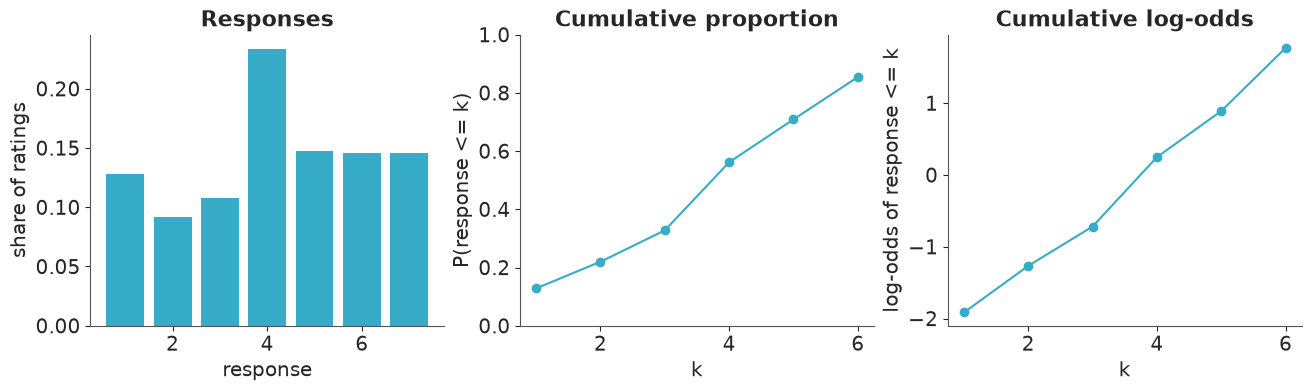

In [4]:
LEVELS = np.arange(1, 8)
obs_freq = trolley.response.value_counts(normalize=True).sort_index()
cum_prop = obs_freq.cumsum().iloc[:-1]
cum_logodds = logit(cum_prop)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].bar(LEVELS, obs_freq, color="C0")
axes[0].set(xlabel="response", ylabel="share of ratings", title="Responses")
axes[1].plot(LEVELS[:-1], cum_prop, "o-")
axes[1].set(xlabel="k", ylabel="P(response <= k)", ylim=(0, 1), title="Cumulative proportion")
axes[2].plot(LEVELS[:-1], cum_logodds, "o-")
axes[2].set(xlabel="k", ylabel="log-odds of response <= k", title="Cumulative log-odds")

pd.DataFrame({"cum_prop": cum_prop, "cum_logodds": cum_logodds}).round(3).T

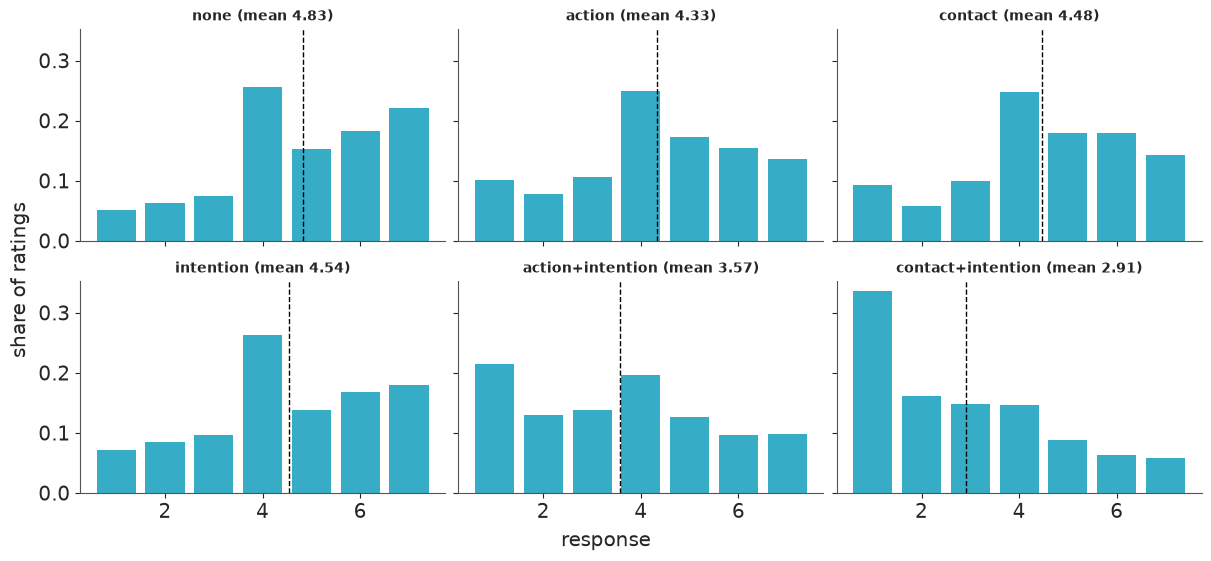

In [5]:
scen_freq = pd.crosstab(trolley.scenario, trolley.response, normalize="index")
scen_mean = trolley.groupby("scenario", observed=True).response.mean()

fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, name in zip(axes.flat, scenarios.index):
    ax.bar(LEVELS, scen_freq.loc[name], color="C0")
    ax.axvline(scen_mean[name], color="k", ls="--", lw=1)
    ax.set_title(f"{name} (mean {scen_mean[name]:.2f})", fontsize=10)
fig.supxlabel("response")
fig.supylabel("share of ratings");

Nothing about this looks Normal. There is a spike at the midpoint 4 ("no opinion"), and the
ends of the scale are piled up: 7 is as popular as 5 or 6 overall, and in
*contact+intention* a third of all ratings sit on the floor at 1. A Normal has one hump, thin
symmetric tails and no idea that 1 and 7 are walls. Notice also that the steps between
consecutive cumulative log-odds are uneven - from 0.55 (between 2 and 3) to 0.97 (between 3
and 4). On the latent scale the categories are **not equally wide**, whereas treating 1-7 as
a metric number assumes that every step is the same size.

## Task 1 · The team's model

This is the model in the team's paper:

$$\text{response}_i \sim \text{Normal}(\mu_i, \sigma), \qquad
\mu_i = a + b_A A_i + b_I I_i + b_C C_i + b_{AI} A_i I_i + b_{CI} C_i I_i$$

**Deliver**
1. The fitted model with clean diagnostics.
2. A posterior predictive check **that you design** to show the team what, if anything, is
   wrong with it. The responses are seven integers and the scenarios are very different from
   one another - a single smoothed density overlay will not do. Make the check reusable: you
   will want to run the *same* check on a better model later.
3. One number for the abstract: what share of the model's predicted ratings are impossible
   (below 1 or above 7)?

### Solution

The priors hardly matter with 9,930 rows; `a` is centred on the middle of the scale and the
slopes allow effects of a couple of rating points either way. One design matrix `X` is
shared by every model in this notebook.

In [6]:
COEFS = ["action", "intention", "contact", "action:intention", "contact:intention"]


def design(df):
    A, I, C = df.action.to_numpy(), df.intention.to_numpy(), df.contact.to_numpy()
    return np.column_stack([A, I, C, A * I, C * I]).astype(float)


X = design(trolley)
X_scen = design(scenarios)  # one row per scenario, for predictions
scen_idx = trolley.scenario.cat.codes.to_numpy()
scen_n = np.bincount(scen_idx)

with pm.Model(coords={"coef": COEFS}) as linear_model:
    a = pm.Normal("a", 4, 2)
    b = pm.Normal("b", 0, 1, dims="coef")
    sigma = pm.HalfNormal("sigma", 2)
    pm.Normal("response", a + pm.math.dot(X, b), sigma, observed=trolley.response.values)
    linear_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(linear_idata.sample_stats["diverging"].sum()))
az.summary(linear_idata, round_to=3)

NUTS[nutpie]: [a, b, sigma]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,4.831,0.044,4.760,4.900,1038.535,1505.796,1.003,0.001,0.001
b[action],-0.505,0.057,-0.594,-0.412,1136.954,1651.932,1.002,0.002,0.001
b[intention],-0.297,0.060,-0.390,-0.200,1034.789,1462.793,1.002,0.002,0.001
b[contact],-0.360,0.071,-0.471,-0.247,1603.831,1834.763,1.001,0.002,0.001
b[action:intention],-0.453,0.081,-0.585,-0.325,1254.365,1828.617,1.002,0.002,0.001
b[contact:intention],-1.264,0.099,-1.425,-1.107,1636.426,2433.184,1.003,0.002,0.001
sigma,1.816,0.013,1.796,1.837,4850.197,2646.732,1.001,0.000,0.000


The sampler is perfectly happy, the intervals are tight, every effect is "significant".
None of that says anything about whether the model can produce data like ours.

**The check.** Simulate replicated datasets and compare, scenario by scenario, the share of
ratings in each of the seven categories. The linear model predicts real numbers, so to give
it the best possible chance we round its predictions to the nearest integer and clip them
to 1-7 - and separately count how often that clipping was needed.

Within a scenario every row has the same $\mu$, so we only need to simulate `n` ratings per
scenario and posterior draw, not push 9,930 x 4,000 numbers through
`pm.sample_posterior_predictive`.

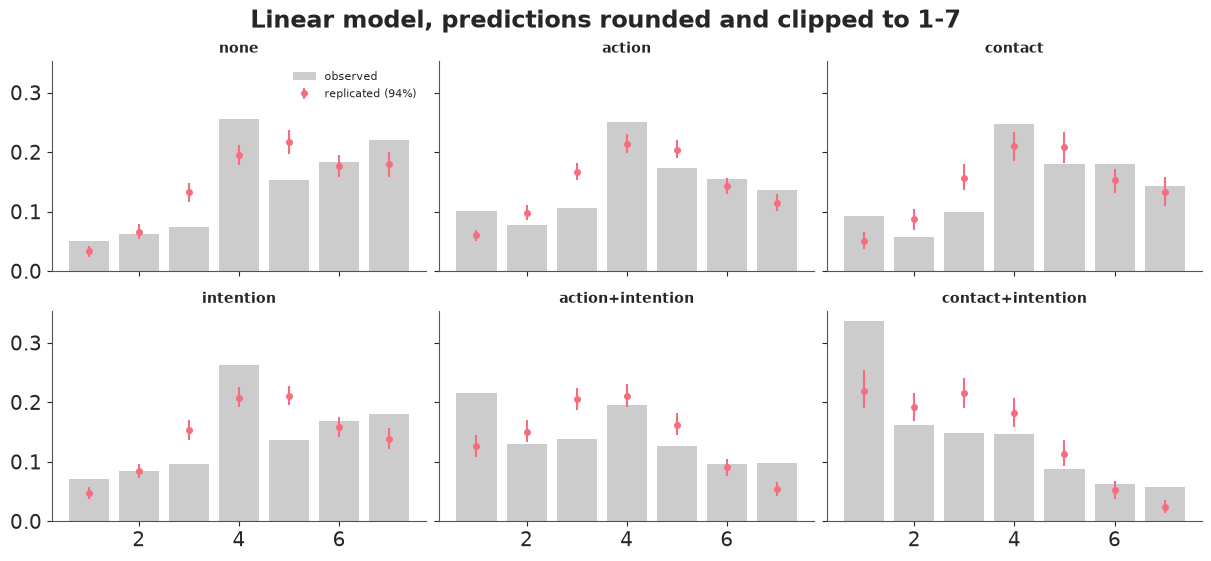

In [7]:
N_REP = 400  # posterior draws used for replicated datasets


def category_freq(y_rep):
    """Share of ratings 1..7 in an array of integer ratings."""
    return np.bincount(y_rep.astype(int), minlength=8)[1:] / y_rep.size


def linear_replicates(idata, n_rep=N_REP):
    """Raw (continuous) replicated ratings per scenario: list of arrays (n_rep, n_scenario_rows)."""
    post = az.extract(idata, num_samples=n_rep, random_seed=RANDOM_SEED)
    mu = post["a"].values[:, None] + post["b"].values.T @ X_scen.T  # (n_rep, 6)
    return [rng.normal(mu[:, [s]], post["sigma"].values[:, None], size=(n_rep, scen_n[s])) for s in range(6)]


def plot_ppc_categories(freq_rep, title, color="C1", axes=None):
    """freq_rep: (n_rep, 6 scenarios, 7 categories) replicated category shares."""
    if axes is None:
        _, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True, sharey=True)
    lo, hi = np.quantile(freq_rep, [0.03, 0.97], axis=0)
    mid = freq_rep.mean(axis=0)
    for s, (ax, name) in enumerate(zip(axes.flat, scenarios.index)):
        ax.bar(LEVELS, scen_freq.loc[name], color="0.8", label="observed")
        ax.errorbar(LEVELS, mid[s], yerr=[mid[s] - lo[s], hi[s] - mid[s]], fmt="o", ms=4, color=color,
                    label="replicated (94%)")
        ax.set_title(name, fontsize=10)
    axes.flat[0].legend(fontsize=8)
    axes.flat[0].figure.suptitle(title)
    return axes


raw = linear_replicates(linear_idata)
linear_freq = np.stack(
    [[category_freq(np.clip(np.rint(r), 1, 7)) for r in raw_s] for raw_s in raw], axis=1
)  # (n_rep, 6, 7)
plot_ppc_categories(linear_freq, "Linear model, predictions rounded and clipped to 1-7");

In [8]:
all_raw = np.concatenate(raw, axis=1)
share_impossible = ((all_raw < 1) | (all_raw > 7)).mean()
by_scen = pd.Series([((r < 1) | (r > 7)).mean() for r in raw], index=scenarios.index)
print(f"share of predicted ratings below 1 or above 7: {share_impossible:.3f}")
print(by_scen.round(3).to_string())

share of predicted ratings below 1 or above 7: 0.118
scenario
none                 0.134
action               0.104
contact              0.111
intention            0.113
action+intention     0.107
contact+intention    0.159


In [9]:
assert h.check(
    "task1",
    sigma=linear_idata.posterior["sigma"].mean(),
    share_impossible=share_impossible,
)

- PASS `sigma` = 1.816 is consistent with the reference solution.
- PASS `share_impossible` = 0.1175 is consistent with the reference solution.

Even with rounding and clipping in its favour, the linear model gets the *shape* wrong in
every scenario, and always in the same way: too many 3s and 5s, too few 4s, and too little
mass at the ends of the scale. It is worst where the mean is closest to a wall: in
*contact+intention* it expects about 22% of ratings to be a 1 when 34% are, and it
under-predicts 7s in *none*. And **12% of its raw predictions are ratings that cannot
exist** (16% in *contact+intention*).

Note what the check did *not* show: the means. Those are fine, as Task 6 will confirm. A
posterior predictive check only exposes what you ask it about.

## Task 2 · An ordinal likelihood

Leave the predictors aside for a moment. Model the seven categories as an **ordered
logistic** outcome: a latent continuous "permissibility" with a logistic distribution, cut
into seven bins by six cutpoints.

**Deliver**
1. Before fitting: what does your prior on the cutpoints imply for the seven category
   probabilities? Show it.
2. The fitted intercept-only model with clean diagnostics. If your first attempt dies
   before a single draw is taken, do not reach for a different sampler - find out *which
   term of the log-probability* is to blame at the starting point, and fix the model.
3. Compare the posterior cutpoints with a number you already have from Task 0. What are
   the cutpoints, in words?

### Solution

`pm.OrderedLogistic` wants categories coded 0..6 and defines
$P(y \le k) = \text{logistic}(c_k - \eta)$. The category probabilities are *differences* of
consecutive cumulative probabilities, so they are only non-negative if
$c_1 < c_2 < \dots < c_6$. Here is what happens when nobody tells the sampler that:

In [10]:
y = trolley.response.values - 1  # 0..6
CUTS = [f"{k}|{k + 1}" for k in range(1, 7)]

with pm.Model(coords={"cutpoint": CUTS}) as unordered_model:
    cut = pm.Normal("cut", 0, 1.5, dims="cutpoint")
    pm.OrderedLogistic("response", eta=0.0, cutpoints=cut, observed=y)

print("log-probability at the starting point:", unordered_model.point_logps())
try:
    with unordered_model:
        pm.sample(random_seed=RANDOM_SEED)
except Exception as err:  # noqa: BLE001
    print(f"\n{type(err).__name__}: {str(err)[:300]}")

NUTS[nutpie]: [cut]


log-probability at the starting point: {'cut': np.float64(-7.95), 'response': np.float64(-inf)}



RuntimeError: All initialization points failed

Caused by:
    Logp function returned error: ErrorCode(4)


The default starting point puts all six cutpoints at 0. Every interior category then has
probability `logistic(0) - logistic(0) = 0`, the data contain thousands of them, and the
log-likelihood is `-inf`. Jittering the start does not help: almost every random
permutation of six numbers is out of order, which gives *negative* probabilities.

The cure has two parts, and you need both:

- `transform=pm.distributions.transforms.ordered` makes the sampler work with
  $(c_1, \log(c_2 - c_1), \dots)$, so every point it visits is ordered;
- an **ordered starting value**. The transform takes the log of the gaps, and the default
  start (all zeros) has gaps of zero - so with the transform alone the model still fails,
  now with `-inf` in the prior term as well.

In [11]:
ordered = pm.distributions.transforms.ordered
CUT_INIT = np.linspace(-2, 2, 6)

with pm.Model(coords={"cutpoint": CUTS}) as transform_only:
    cut = pm.Normal("cut", 0, 1.5, dims="cutpoint", transform=ordered)
    pm.OrderedLogistic("response", eta=0.0, cutpoints=cut, observed=y)
print("ordered transform, default start:", transform_only.point_logps())

ordered transform, default start: {'cut': np.float64(-inf), 'response': np.float64(-inf)}


**Prior.** On the log-odds scale ±4 already means 2% and 98%, so `Normal(0, 1.5)` for each
cutpoint is weakly informative. With the ordered transform the prior is that density
restricted to ordered vectors - which is the distribution of six *sorted* independent
draws. (`pm.sample_prior_predictive` ignores transforms and would hand you unsorted
cutpoints, so we do this one by hand.)

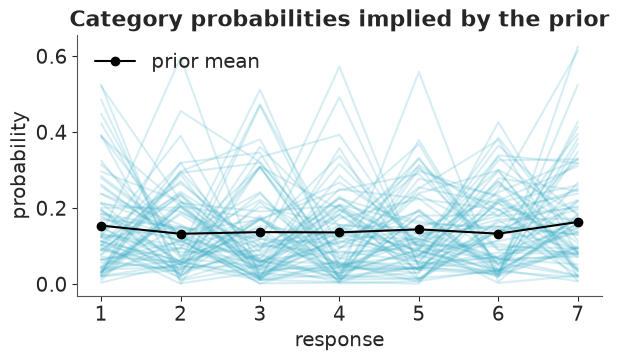

In [12]:
def ordinal_probs(eta, cut):
    """Category probabilities. eta: (...,), cut: (..., 6) -> (..., 7)."""
    cdf = expit(cut - np.asarray(eta)[..., None])
    cdf = np.concatenate([np.zeros_like(cdf[..., :1]), cdf, np.ones_like(cdf[..., :1])], axis=-1)
    return np.diff(cdf, axis=-1)


prior_cut = np.sort(rng.normal(0, 1.5, size=(500, 6)), axis=1)
prior_p = ordinal_probs(np.zeros(500), prior_cut)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(LEVELS, prior_p[:80].T, color="C0", alpha=0.2)
ax.plot(LEVELS, prior_p.mean(axis=0), "k-o", label="prior mean")
ax.set(xlabel="response", ylabel="probability", title="Category probabilities implied by the prior")
ax.legend();

On average the prior spreads probability almost evenly over the seven categories (about
1/7 each), while single draws range from nearly empty categories to ones holding more
than half of the mass. That is as vague as we want to be: nothing is ruled out, and no
category is favoured.

In [13]:
with pm.Model(coords={"cutpoint": CUTS}) as cut_model:
    cut = pm.Normal("cut", 0, 1.5, dims="cutpoint", transform=ordered)
    pm.OrderedLogistic("response", eta=0.0, cutpoints=cut, observed=y)
    cut_idata = pm.sample(initvals={"cut": CUT_INIT}, random_seed=RANDOM_SEED)

print("divergences:", int(cut_idata.sample_stats["diverging"].sum()))
az.summary(cut_idata, var_names=["cut"], round_to=3)

NUTS[nutpie]: [cut]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cut[1|2],-1.917,0.031,-1.966,-1.867,2969.036,2609.905,1.001,0.001,0.0
cut[2|3],-1.267,0.024,-1.305,-1.229,4170.231,2927.030,1.000,0.000,0.0
cut[3|4],-0.718,0.021,-0.752,-0.686,4823.500,3728.625,1.000,0.000,0.0
cut[4|5],0.248,0.020,0.214,0.281,5937.256,3977.919,1.001,0.000,0.0
cut[5|6],0.890,0.022,0.855,0.924,5835.405,3543.553,1.001,0.000,0.0
cut[6|7],1.770,0.028,1.726,1.813,6194.230,4059.326,1.002,0.000,0.0


In [14]:
cut_mean = cut_idata.posterior["cut"].mean(("chain", "draw")).values
print(pd.DataFrame({"posterior mean": cut_mean, "empirical log-odds": cum_logodds.values}, index=CUTS).round(3))
assert h.check("task2", cut_first=cut_mean[0], cut_last=cut_mean[-1])

     posterior mean  empirical log-odds
1|2          -1.917              -1.916
2|3          -1.267              -1.267
3|4          -0.718              -0.719
4|5           0.248               0.248
5|6           0.890               0.890
6|7           1.770               1.769


- PASS `cut_first` = -1.917 is consistent with the reference solution.
- PASS `cut_last` = 1.77 is consistent with the reference solution.

The posterior means reproduce the empirical cumulative log-odds from Task 0 to within
0.001. With no predictors that is all the cutpoints are: **the log-odds of responding at
most k**, six free numbers that can match any histogram over seven categories. The spike at
4 and the pile-ups at 1 and 7 cost this model nothing. Everything that follows keeps that
flexibility and lets predictors shift the whole latent scale.

## Task 3 · Ordinal regression

Add the team's predictors - action, intention, contact and the two interactions with
intention - to the ordinal model, with the convention that a **positive coefficient means
"more permissible"**.

**Deliver**
1. Priors for the coefficients that you can defend on the log-odds scale.
2. The fitted model with clean diagnostics. (Memory warning: by default
   `pm.OrderedLogistic` stores the seven category probabilities of *every row* for every
   draw. With 9,930 rows that is gigabytes. Find the switch.)
3. Your Task 1 check, run on this model and shown next to the linear one.

### Solution

A coefficient of 1 on the log-odds scale is a large effect: it moves a 50% cumulative
probability to 27%. `Normal(0, 0.5)` says effects beyond ±1 are unlikely but possible.
There is **no intercept**: the six cutpoints already are six intercepts, and adding a
seventh would make the model non-identified.

In [15]:
with pm.Model(coords={"cutpoint": CUTS, "coef": COEFS}) as ordinal_model:
    cut = pm.Normal("cut", 0, 1.5, dims="cutpoint", transform=ordered)
    b = pm.Normal("b", 0, 0.5, dims="coef")
    pm.OrderedLogistic("response", eta=pm.math.dot(X, b), cutpoints=cut, observed=y, compute_p=False)
    ordinal_idata = pm.sample(initvals={"cut": CUT_INIT}, random_seed=RANDOM_SEED)

print("divergences:", int(ordinal_idata.sample_stats["diverging"].sum()))
az.summary(ordinal_idata, round_to=3)

NUTS[nutpie]: [cut, b]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b[action],-0.470,0.054,-0.555,-0.384,1538.959,1811.296,1.001,0.001,0.001
b[intention],-0.289,0.057,-0.382,-0.199,1459.904,1789.584,1.002,0.001,0.001
b[contact],-0.340,0.068,-0.448,-0.230,1715.576,2217.699,1.001,0.002,0.001
b[action:intention],-0.438,0.078,-0.562,-0.311,1759.739,2137.349,1.000,0.002,0.001
b[contact:intention],-1.240,0.098,-1.396,-1.087,1862.529,2345.156,1.001,0.002,0.001
cut[1|2],-2.630,0.052,-2.715,-2.549,1285.449,1530.077,1.001,0.001,0.001
cut[2|3],-1.935,0.048,-2.012,-1.860,1382.083,1651.057,1.002,0.001,0.001
cut[3|4],-1.341,0.046,-1.414,-1.269,1436.048,1635.069,1.002,0.001,0.001
cut[4|5],-0.307,0.044,-0.377,-0.237,1429.515,1717.955,1.003,0.001,0.001
cut[5|6],0.364,0.043,0.294,0.433,1463.234,1981.270,1.002,0.001,0.001


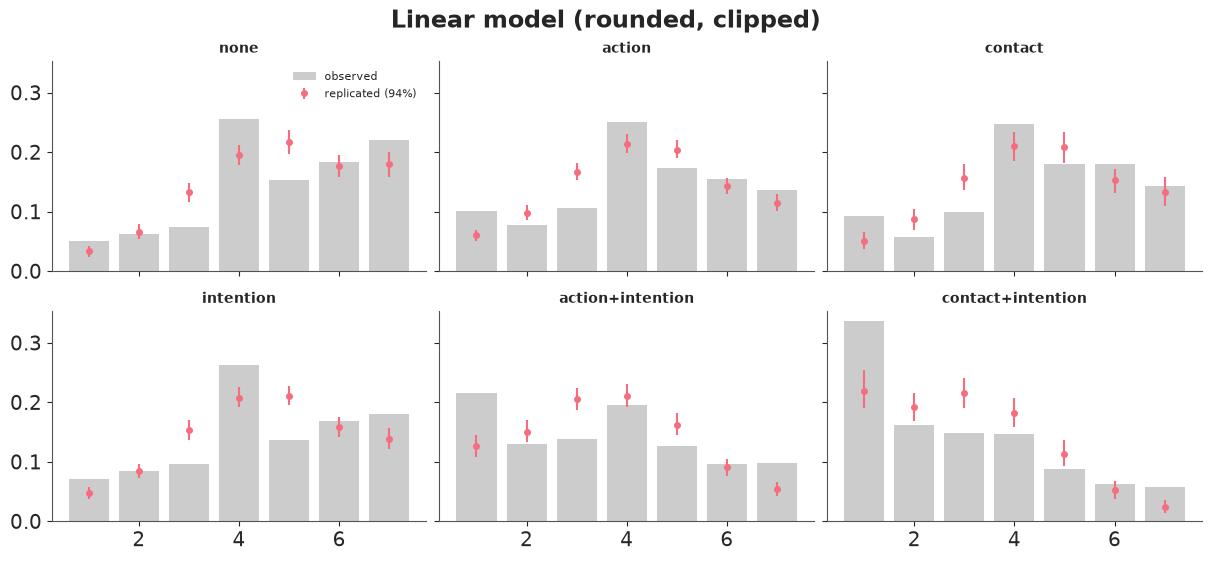

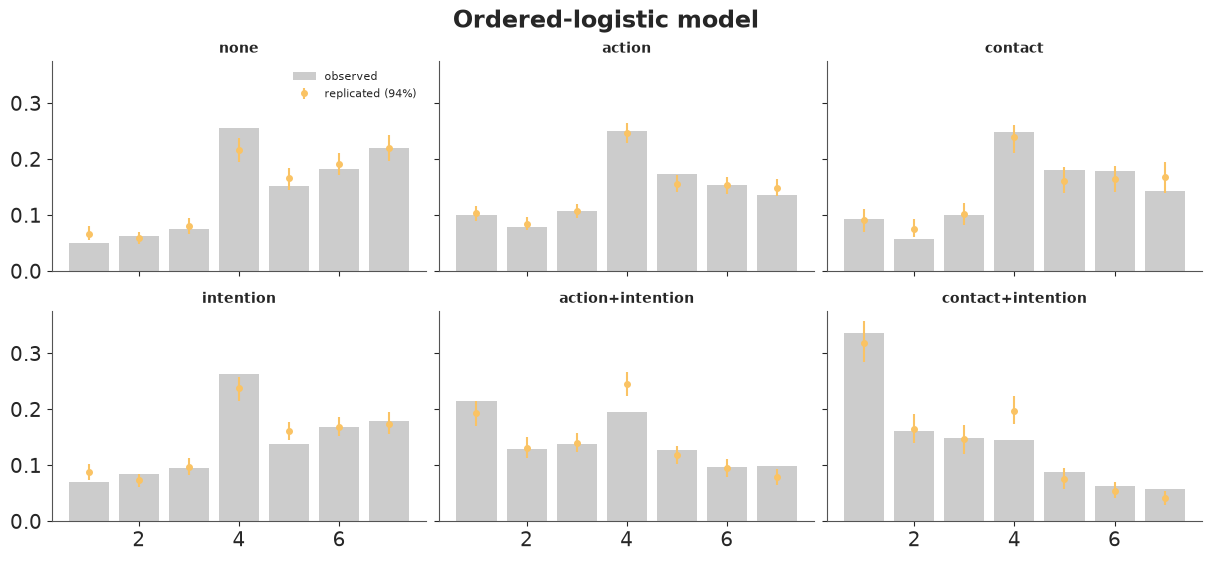

In [16]:
def scenario_probs(idata, num_samples=None):
    """Posterior category probabilities per scenario: (draws, 6 scenarios, 7 categories)."""
    post = az.extract(idata, var_names=["b", "cut"], num_samples=num_samples, random_seed=RANDOM_SEED)
    eta = post["b"].values.T @ X_scen.T  # (draws, 6)
    return ordinal_probs(eta, post["cut"].values.T[:, None, :])


p_rep = scenario_probs(ordinal_idata, num_samples=N_REP)
ordinal_freq = np.stack(
    [[rng.multinomial(scen_n[s], p_draw[s]) / scen_n[s] for s in range(6)] for p_draw in p_rep]
)  # (n_rep, 6, 7)

plot_ppc_categories(linear_freq, "Linear model (rounded, clipped)", color="C1")
plot_ppc_categories(ordinal_freq, "Ordered-logistic model", color="C2");

In [17]:
def ppc_error(freq_rep):
    """Mean absolute error of the replicated category shares, in percentage points, per scenario."""
    err = np.abs(freq_rep.mean(axis=0) - scen_freq.values).mean(axis=1) * 100
    return pd.Series(err, index=scenarios.index)


pd.DataFrame({"linear": ppc_error(linear_freq), "ordinal": ppc_error(ordinal_freq)}).round(2)

,linear,ordinal
scenario,,
none,3.57,1.23
action,3.15,0.62
contact,3.30,1.28
intention,3.72,1.23
action+intention,3.99,1.52
contact+intention,4.59,1.58


In [18]:
b_mean = ordinal_idata.posterior["b"].mean(("chain", "draw"))
assert h.check(
    "task3",
    b_action=b_mean.sel(coef="action"),
    b_intention=b_mean.sel(coef="intention"),
    b_contact=b_mean.sel(coef="contact"),
    b_contact_intention=b_mean.sel(coef="contact:intention"),
)

- PASS `b_action` = -0.4702 is consistent with the reference solution.
- PASS `b_intention` = -0.2888 is consistent with the reference solution.
- PASS `b_contact` = -0.34 is consistent with the reference solution.
- PASS `b_contact_intention` = -1.24 is consistent with the reference solution.

All five coefficients are negative: every feature makes the act less permissible, and
intention combined with contact (-1.24) far more than the sum of its parts.

On the same check the ordinal model cuts the average error in the category shares from
3-5 percentage points to 0.6-1.6, and it cannot produce an impossible rating. The floor in
*contact+intention* and the ceiling in *none* are now reproduced.

It is not perfect, and the check shows where: in the two harshest scenarios it predicts
too many 4s (about 24% against 20% observed in *action+intention*, 20% against 15% in
*contact+intention*). The model assumes **proportional odds** - predictors slide the whole
latent distribution past fixed cutpoints - but people who condemn these acts seem to
abandon the neutral midpoint faster than that allows. That is a lead for "Going further",
and a much smaller problem than the one we started with.

## Task 4 · Back to the scale people answered on

"The contact:intention coefficient is -1.2 on the latent log-odds scale" is not a sentence
you can put in front of the survey team.

**Deliver**, from the ordinal model, with 94% intervals:
1. A figure of the predicted distribution over the seven categories for each scenario.
2. A table with the expected rating and $P(\text{response} \le 3)$ ("leans impermissible")
   for each scenario.
3. The headline contrast: going from *none* to *contact+intention*, how much does the
   expected rating fall, and by how many percentage points does $P(\text{response} \le 3)$ rise?

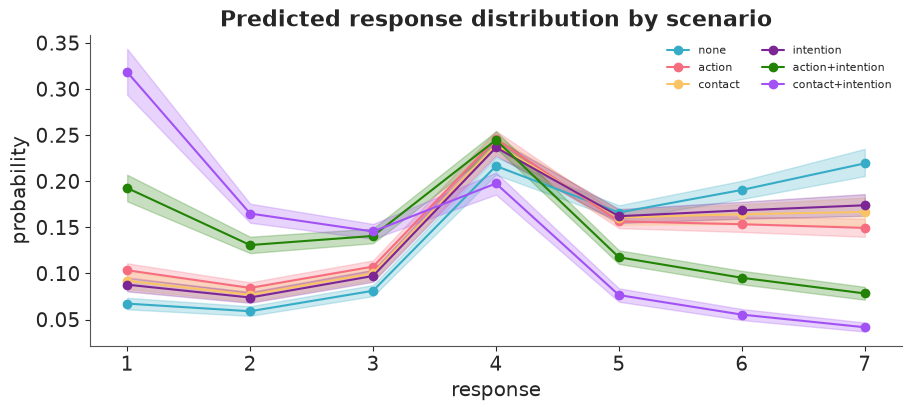

In [19]:
P_ord = scenario_probs(ordinal_idata)  # (draws, 6, 7)
mean_ord = (P_ord * LEVELS).sum(axis=-1)  # (draws, 6)
le3_ord = P_ord[..., :3].sum(axis=-1)


def summarise(draws, index, name):
    lo, hi = np.quantile(draws, [0.03, 0.97], axis=0)
    return pd.DataFrame({name: draws.mean(axis=0), "lo": lo, "hi": hi}, index=index)


fig, ax = plt.subplots(figsize=(9, 4))
lo, hi = np.quantile(P_ord, [0.03, 0.97], axis=0)
for s, name in enumerate(scenarios.index):
    ax.plot(LEVELS, P_ord[:, s].mean(axis=0), "o-", color=f"C{s}", label=name)
    ax.fill_between(LEVELS, lo[s], hi[s], color=f"C{s}", alpha=0.25)
ax.set(xlabel="response", ylabel="probability", title="Predicted response distribution by scenario")
ax.legend(fontsize=8, ncol=2);

In [20]:
pd.concat(
    {
        "expected rating": summarise(mean_ord, scenarios.index, "mean"),
        "P(response <= 3)": summarise(le3_ord, scenarios.index, "mean"),
    },
    axis=1,
).round(3)

expected rating               P(response <= 3)              
                             mean     lo     hi             mean     lo     hi
scenario                                                                      
none                        4.804  4.727  4.884            0.207  0.194  0.222
action                      4.325  4.258  4.392            0.295  0.281  0.310
contact                     4.460  4.353  4.563            0.269  0.249  0.291
intention                   4.512  4.438  4.587            0.259  0.244  0.274
action+intention            3.563  3.478  3.649            0.464  0.443  0.485
contact+intention           2.881  2.775  2.987            0.629  0.602  0.655

In [21]:
NONE, CI = 0, 5  # positions of "none" and "contact+intention" in `scenarios`
shift_mean = mean_ord[:, CI] - mean_ord[:, NONE]
shift_le3 = le3_ord[:, CI] - le3_ord[:, NONE]
for label, d, scale in [("expected rating", shift_mean, 1), ("P(response <= 3), pct points", shift_le3, 100)]:
    print(f"none -> contact+intention, {label}: {scale * d.mean():.2f} "
          f"[{scale * np.quantile(d, 0.03):.2f}, {scale * np.quantile(d, 0.97):.2f}]")

assert h.check(
    "task4",
    mean_none=mean_ord[:, NONE].mean(),
    p_le3_contact_intention=le3_ord[:, CI].mean(),
    shift_mean=shift_mean.mean(),
)

none -> contact+intention, expected rating: -1.92 [-2.06, -1.79]
none -> contact+intention, P(response <= 3), pct points: 42.14 [39.18, 45.07]


- PASS `mean_none` = 4.804 is consistent with the reference solution.
- PASS `p_le3_contact_intention` = 0.6289 is consistent with the reference solution.
- PASS `shift_mean` = -1.923 is consistent with the reference solution.

In the team's language: with none of the three features present the expected rating is
4.8 and about one rating in five leans impermissible (3 or lower). When the death is
intended **and** involves physical contact, the expected rating falls by **1.9 points** to
2.9, and the share leaning impermissible triples to 63% - a rise of **42 percentage
points** (94% interval 39-45). Almost a third of respondents then choose the very lowest
category.

Everything here was computed per posterior draw and summarised last, which is why each
number comes with an interval. Coefficients on the latent scale have no such direct
reading: the same shift in $\eta$ moves more or less probability depending on where the
cutpoints are.

## Task 5 · People differ

Every participant rated 30 stories, and so far the models have treated their 30 answers as
independent. Some people are strict, some lenient; some stories are simply more upsetting
than others whatever their features.

To stay inside a laptop runtime budget this task uses a **random subsample of 150
participants** (4,500 ratings), defined below. Use it for every model in this task so that
they can be compared.

**Deliver**
1. An ordinal model with a varying intercept per participant and an effect per story,
   with clean diagnostics. 150 correlated intercepts next to six cutpoints is a
   location-identification problem waiting to happen - deal with it in the model.
2. How large is the between-participant standard deviation compared with the biggest
   treatment effect? Put it in words.
3. A LOO comparison with the Task 3 model refitted to the same subsample. How much do the
   participant and story effects matter for prediction?
4. Put the coefficients of the two models side by side. They all moved *away* from zero.
   Explain why that is expected and not a contradiction.

In [22]:
# a dedicated generator, so that everybody gets the same 150 people whatever was run before
sub_ids = np.sort(np.random.default_rng(RANDOM_SEED).choice(trolley.id.unique(), size=150, replace=False))
sub = trolley[trolley.id.isin(sub_ids)].reset_index(drop=True)
print(f"{sub.id.nunique()} participants, {len(sub)} ratings")

150 participants, 4500 ratings


### Solution

The cutpoints fix the location of the latent scale, so the participant and story effects
must not be able to shift it as well. `pm.ZeroSumNormal` builds the sum-to-zero constraint
into the prior, which removes that ridge from the posterior instead of leaving NUTS to
crawl along it. With 30 ratings per person the intercepts are well informed by the data,
so the centred form (scale inside the distribution) samples well; with few ratings per
group you would switch to a non-centred one.

In [23]:
X_sub, y_sub = design(sub), sub.response.values - 1
pid, participants = pd.factorize(sub.id, sort=True)
sid, stories = pd.factorize(sub.story, sort=True)

with pm.Model(coords={"cutpoint": CUTS, "coef": COEFS}) as pop_sub_model:
    cut = pm.Normal("cut", 0, 1.5, dims="cutpoint", transform=ordered)
    b = pm.Normal("b", 0, 0.5, dims="coef")
    pm.OrderedLogistic("response", eta=pm.math.dot(X_sub, b), cutpoints=cut, observed=y_sub, compute_p=False)
    pop_sub_idata = pm.sample(initvals={"cut": CUT_INIT}, random_seed=RANDOM_SEED)
    pm.compute_log_likelihood(pop_sub_idata, progressbar=False)

coords = {"cutpoint": CUTS, "coef": COEFS, "participant": participants, "story": stories}
with pm.Model(coords=coords) as hier_model:
    cut = pm.Normal("cut", 0, 1.5, dims="cutpoint", transform=ordered)
    b = pm.Normal("b", 0, 0.5, dims="coef")
    sigma_participant = pm.HalfNormal("sigma_participant", 1.5)
    sigma_story = pm.HalfNormal("sigma_story", 1.0)
    u = pm.ZeroSumNormal("u", sigma_participant, dims="participant")
    v = pm.ZeroSumNormal("v", sigma_story, dims="story")
    eta = pm.math.dot(X_sub, b) + u[pid] + v[sid]
    pm.OrderedLogistic("response", eta=eta, cutpoints=cut, observed=y_sub, compute_p=False)
    hier_idata = pm.sample(initvals={"cut": CUT_INIT}, nuts_sampler="nutpie", random_seed=RANDOM_SEED)
    pm.compute_log_likelihood(hier_idata, progressbar=False)

print("divergences:", int(hier_idata.sample_stats["diverging"].sum()))
az.summary(hier_idata, var_names=["cut", "b", "sigma_participant", "sigma_story"], round_to=3)

NUTS[nutpie]: [cut, b]


NUTS[nutpie]: [cut, b, sigma_participant, sigma_story, u, v]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cut[1|2],-3.836,0.099,-3.995,-3.677,1569.922,1861.666,1.002,0.003,0.002
cut[2|3],-2.897,0.091,-3.043,-2.749,1648.559,2279.836,1.002,0.002,0.001
cut[3|4],-2.108,0.087,-2.245,-1.969,1678.242,2298.232,1.003,0.002,0.001
cut[4|5],-0.456,0.084,-0.590,-0.319,1634.170,2256.081,1.002,0.002,0.001
cut[5|6],0.632,0.084,0.498,0.768,1770.263,2193.335,1.002,0.002,0.001
cut[6|7],1.919,0.092,1.771,2.066,1908.585,2681.872,1.002,0.002,0.001
b[action],-0.911,0.097,-1.064,-0.752,1596.559,2298.651,1.002,0.002,0.001
b[intention],-0.433,0.099,-0.588,-0.270,1945.051,2471.283,1.001,0.002,0.001
b[contact],-1.133,0.141,-1.359,-0.908,1927.019,2334.942,1.002,0.003,0.002
b[action:intention],-0.506,0.124,-0.702,-0.312,2693.341,2845.136,1.000,0.002,0.002


In [24]:
worst = az.summary(hier_idata, var_names=["u", "v"])
print(f"participant and story effects: max r_hat {worst.r_hat.max():.3f}, min bulk ESS {worst.ess_bulk.min():.0f}")

b_compare = pd.DataFrame({
    "population": pop_sub_idata.posterior["b"].mean(("chain", "draw")).to_series(),
    "hierarchical": hier_idata.posterior["b"].mean(("chain", "draw")).to_series(),
})
b_compare["ratio"] = b_compare.hierarchical / b_compare.population
sd_p = float(hier_idata.posterior["sigma_participant"].mean())
print(f"scaling expected from ignoring participants: {np.sqrt(1 + sd_p**2 / (np.pi**2 / 3)):.2f}")
b_compare.round(2)

participant and story effects: max r_hat 1.005, min bulk ESS 5047
scaling expected from ignoring participants: 1.51


,population,hierarchical,ratio
coef,,,
action,-0.51,-0.91,1.79
intention,-0.24,-0.43,1.78
contact,-0.46,-1.13,2.47
action:intention,-0.40,-0.51,1.27
contact:intention,-1.14,-1.21,1.06


In [25]:
comparison = az.compare({"population": pop_sub_idata, "hierarchical": hier_idata})
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
hierarchical,0,0.0,0.0,NaN,,,175.5,-6800.0,63.0,0.92
population,1,-1500.0,60.0,1.0,,,11.0,-8330.0,29.0,0.08


In [26]:
elpd_diff = comparison.loc["hierarchical", "elpd"] - comparison.loc["population", "elpd"]
print(f"elpd difference: {elpd_diff:.0f}, i.e. {elpd_diff / len(sub):.3f} per rating; "
      f"exp of that = {np.exp(elpd_diff / len(sub)):.2f}")
assert h.check(
    "task5",
    sigma_participant=hier_idata.posterior["sigma_participant"].mean(),
    elpd_diff=elpd_diff,
)

elpd difference: 1530, i.e. 0.340 per rating; exp of that = 1.40


- PASS `sigma_participant` = 2.053 is consistent with the reference solution.
- PASS `elpd_diff` = 1530 is consistent with the reference solution.

**Diagnostics.** No divergences, `r_hat` of 1.00-1.01 everywhere, and thousands of effective
draws even for the 150 participant intercepts.

**People matter more than the experiment.** The between-participant standard deviation is
about 2.1 on the log-odds scale - 1.7 times the largest treatment coefficient (-1.2). A
participant one sd below average rates the harmless *none* stories around 3.3, one sd above
around 6.2 (you will compute this in Task 6). Stories differ too (sd about 0.5), but far less.

**LOO.** The hierarchical model is better by about 1,500 elpd (standard error 60) on 4,500
ratings. Per rating that is 0.34 nats: knowing who is answering makes the observed rating
on average 1.4 times more probable under the model. It pays for this with about 175
effective parameters instead of 11. No Pareto-k warnings, so the comparison can be trusted.

**Why the coefficients grew.** Two things happen at once.

1. A logit coefficient is measured in units of the *unexplained* latent spread. The
   population model lumps the between-person variation into that spread, so its coefficients
   describe a flatter, population-averaged curve. Conditioning on the person removes it and
   the same effect is a larger number of (smaller) units - by a factor of about
   $\sqrt{1 + \sigma_u^2 / (\pi^2/3)} \approx 1.5$ here. This is the non-collapsibility
   of the logit link, not a change in what the data say.
2. Features and stories are not fully crossed (contact occurs in only five of the twelve
   stories), so once stories have their own effects the split between main effects and
   interactions shifts. That is why the ratios are not all 1.5: main effects grew by
   1.8-2.5, the interactions by 1.1-1.3.

The lesson: **never compare raw coefficients between a population and a hierarchical
logit model**. Compare predictions on the outcome scale.

## Task 6 · So was the reviewer right?

Time to answer the team lead. Use the two population models fitted to the full data
(Tasks 1 and 3) and, for the last part, the hierarchical model.

**Deliver**
1. For **every pair of scenarios** (15 pairs) the effect of moving from one to the other
   according to each model and according to the raw data, on three quantities: the expected
   rating, $P(\text{response} \le 3)$ and $P(\text{response} = 1)$ ("absolutely
   impermissible"). For the linear model, take its predictive distribution rounded to the
   nearest category, with everything below 1.5 counted as 1 and everything above 6.5 as 7.
   For which pair, and which quantity, do the two models disagree most - and which of them
   is closer to the data?
2. The linear model says the *none → contact+intention* drop is the same number of rating
   points for everybody. What does the hierarchical ordinal model say for a typical
   participant, a strict one (2 sd below) and a lenient one (2 sd above)? Is there any
   sign of this in the raw data?
3. A paragraph for the team lead: which of their conclusions survive, which do not, and
   what should they change?

In [27]:
post_lin = az.extract(linear_idata, var_names=["a", "b", "sigma"])
mu_lin = post_lin["a"].values[:, None] + post_lin["b"].values.T @ X_scen.T  # (draws, 6)
edges = np.array([-np.inf, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, np.inf])
P_lin = np.diff(
    stats.norm.cdf((edges - mu_lin[..., None]) / post_lin["sigma"].values[:, None, None]), axis=-1
)  # (draws, 6, 7)

quantities = {
    "expected rating": (scen_mean.values, mu_lin.mean(axis=0), mean_ord.mean(axis=0)),
    "P(<=3)": (scen_freq.values[:, :3].sum(axis=1), P_lin[..., :3].sum(-1).mean(0), le3_ord.mean(0)),
    "P(=1)": (scen_freq.values[:, 0], P_lin[..., 0].mean(0), P_ord[..., 0].mean(0)),
}
levels = pd.concat(
    {q: pd.DataFrame(dict(zip(["observed", "linear", "ordinal"], vals)), index=scenarios.index)
     for q, vals in quantities.items()},
    axis=1,
)
levels.round(3)

expected rating                  P(<=3)                 \
                         observed linear ordinal observed linear ordinal   
scenario                                                                   
none                        4.829  4.831   4.804    0.188  0.232   0.207   
action                      4.326  4.326   4.325    0.286  0.325   0.295   
contact                     4.475  4.471   4.460    0.250  0.296   0.269   
intention                   4.535  4.533   4.512    0.251  0.285   0.259   
action+intention            3.574  3.575   3.563    0.482  0.483   0.464   
contact+intention           2.906  2.910   2.881    0.646  0.627   0.629   

                     P(=1)                 
                  observed linear ordinal  
scenario                                   
none                 0.051  0.033   0.067  
action               0.101  0.060   0.103  
contact              0.093  0.051   0.092  
intention            0.071  0.047   0.088  
action+intention     0.215  0.127   0.193  
contact+intention    0.336  0.219   0.318

In [28]:
pairs = [(i, j) for i in range(6) for j in range(i + 1, 6)]
pair_names = [f"{scenarios.index[i]} -> {scenarios.index[j]}" for i, j in pairs]
effects = pd.concat(
    {q: pd.DataFrame({m: [levels[q][m].iloc[j] - levels[q][m].iloc[i] for i, j in pairs]
                      for m in ["observed", "linear", "ordinal"]}, index=pair_names)
     for q in quantities},
    axis=1,
)
gap = pd.DataFrame({q: (effects[q]["linear"] - effects[q]["ordinal"]).abs() for q in quantities})
effects.round(3)

expected rating                  P(<=3)  \
                                             observed linear ordinal observed   
none -> action                                 -0.503 -0.505  -0.479    0.098   
none -> contact                                -0.354 -0.360  -0.345    0.062   
none -> intention                              -0.294 -0.297  -0.292    0.063   
none -> action+intention                       -1.255 -1.256  -1.242    0.294   
none -> contact+intention                      -1.923 -1.921  -1.923    0.458   
action -> contact                               0.149  0.145   0.135   -0.036   
action -> intention                             0.209  0.208   0.187   -0.035   
action -> action+intention                     -0.752 -0.751  -0.762    0.196   
action -> contact+intention                    -1.420 -1.416  -1.444    0.360   
contact -> intention                            0.060  0.062   0.053    0.002   
contact -> action+intention                    -0.901 -0.896  -0.897    0.232   
contact -> contact+intention                   -1.569 -1.561  -1.578    0.396   
intention -> action+intention                  -0.961 -0.958  -0.949    0.231   
intention -> contact+intention                 -1.629 -1.624  -1.631    0.394   
action+intention -> contact+intention          -0.668 -0.665  -0.682    0.163   

                                                        P(=1)                 
                                      linear ordinal observed linear ordinal  
none -> action                         0.093   0.088    0.050  0.027   0.036  
none -> contact                        0.065   0.061    0.042  0.018   0.025  
none -> intention                      0.053   0.051    0.020  0.014   0.021  
none -> action+intention               0.252   0.257    0.164  0.093   0.125  
none -> contact+intention              0.395   0.421    0.286  0.186   0.251  
action -> contact                     -0.028  -0.026   -0.008 -0.009  -0.011  
action -> intention                   -0.040  -0.036   -0.030 -0.012  -0.016  
action -> action+intention             0.159   0.169    0.114  0.067   0.089  
action -> contact+intention            0.303   0.334    0.236  0.159   0.215  
contact -> intention                  -0.012  -0.010   -0.022 -0.004  -0.004  
contact -> action+intention            0.187   0.195    0.122  0.076   0.101  
contact -> contact+intention           0.331   0.360    0.244  0.168   0.226  
intention -> action+intention          0.199   0.205    0.144  0.079   0.105  
intention -> contact+intention         0.343   0.370    0.265  0.171   0.231  
action+intention -> contact+intention  0.144   0.165    0.121  0.092   0.126

In [29]:
for q in quantities:
    worst_pair = gap[q].idxmax()
    print(f"{q:16s} largest disagreement {gap[q].max():.3f} for {worst_pair}: "
          + ", ".join(f"{m} {effects[q][m][worst_pair]:+.3f}" for m in ["observed", "linear", "ordinal"]))

expected rating  largest disagreement 0.028 for action -> contact+intention: observed -1.420, linear -1.416, ordinal -1.444
P(<=3)           largest disagreement 0.031 for action -> contact+intention: observed +0.360, linear +0.303, ordinal +0.334
P(=1)            largest disagreement 0.066 for none -> contact+intention: observed +0.286, linear +0.186, ordinal +0.251


**Expected ratings: no disagreement worth the name.** Over all 15 pairs the two models never
differ by more than 0.03 rating points, and both match the raw differences in means. This is
no accident: there are six scenarios and the linear model has six mean parameters, so it is
*saturated* - it reproduces the six cell means whatever shape the residuals have. Signs,
ranking and the intention x contact interaction all survive.

**Proportions: this is where it bites.** For $P(\text{response} \le 3)$ the models differ by
up to 3 percentage points, and the linear model is the one further from the data (action ->
contact+intention: observed +36, ordinal +33, linear +30). For the bottom category the gap
doubles: going from *none* to *contact+intention*, the share answering "absolutely
impermissible" rises by 29 points in the data, 25 under the ordinal model and **19 under
the linear model - a third of the effect is missing**. The threshold 3.5 sits near the
middle of the scale, where a Normal is least wrong; the further out you ask, the worse it gets.

In [30]:
post_h = az.extract(hier_idata, var_names=["b", "cut", "sigma_participant"])
b_h, cut_h = post_h["b"].values.T, post_h["cut"].values.T
eta_pair = b_h @ X_scen[[NONE, CI]].T  # (draws, 2): none, contact+intention - average story

rows = {}
for label, z in [("strict (-2 sd)", -2), ("-1 sd", -1), ("typical", 0), ("+1 sd", 1), ("lenient (+2 sd)", 2)]:
    eta_z = eta_pair + z * post_h["sigma_participant"].values[:, None]
    m = (ordinal_probs(eta_z, cut_h[:, None, :]) * LEVELS).sum(axis=-1)  # (draws, 2)
    d = m[:, 1] - m[:, 0]
    rows[label] = {"rating in 'none'": m[:, 0].mean(), "drop": d.mean(),
                   "lo": np.quantile(d, 0.03), "hi": np.quantile(d, 0.97)}
drops = pd.DataFrame(rows).T
print(f"linear model, everybody: {(mu_lin[:, CI] - mu_lin[:, NONE]).mean():.2f}")
drops.round(2)

linear model, everybody: -1.92


,rating in 'none',drop,lo,hi
strict (-2 sd),1.83,-0.75,-1.00,-0.51
-1 sd,3.32,-1.84,-2.02,-1.65
typical,4.91,-2.16,-2.36,-1.95
+1 sd,6.24,-1.87,-2.06,-1.67
lenient (+2 sd),6.85,-1.03,-1.29,-0.75


In [31]:
# Raw data: group participants by how lenient they are on the OTHER four scenarios, so that the
# grouping variable does not contain the two scenarios being compared.
is_pair = trolley.scenario.isin(["none", "contact+intention"])
leniency = trolley[~is_pair].groupby("id").response.mean()
cell = trolley[is_pair].pivot_table(index="id", columns="scenario", values="response", aggfunc="mean",
                                    observed=True)
fifth = pd.qcut(leniency, 5, labels=["strictest fifth", "2", "3", "4", "most lenient fifth"])
raw_drop = pd.DataFrame({
    "rating on other scenarios": leniency.groupby(fifth, observed=True).mean(),
    "rating in 'none'": cell["none"].groupby(fifth, observed=True).mean(),
    "observed drop": (cell["contact+intention"] - cell["none"]).groupby(fifth, observed=True).mean(),
})
raw_drop.round(2)

,rating on other scenarios,rating in 'none',observed drop
response,,,
strictest fifth,2.60,3.93,-2.61
2,3.60,4.20,-2.14
3,4.20,4.50,-1.58
4,4.87,5.32,-1.87
most lenient fifth,6.05,6.28,-1.32


In [32]:
assert h.check(
    "task6",
    max_gap_mean=gap["expected rating"].max(),
    max_gap_p1=gap["P(=1)"].max(),
    drop_typical=drops.loc["typical", "drop"],
    drop_lenient=drops.loc["lenient (+2 sd)", "drop"],
)

- PASS `max_gap_mean` = 0.02772 is consistent with the reference solution.
- PASS `max_gap_p1` = 0.06565 is consistent with the reference solution.
- PASS `drop_typical` = -2.16 is consistent with the reference solution.
- PASS `drop_lenient` = -1.025 is consistent with the reference solution.

**Is the effect the same for everybody?** The linear model has to say yes: 1.9 points. The
hierarchical ordinal model says a typical participant drops by about 2.2 points, but someone
two sd stricter or more lenient by only 0.8-1.0, because a person who already answers 1.8
or 6.9 has little scale left to move on.

The raw data agree that the effect is **not** constant - the observed drop ranges from 2.6
points in the strictest fifth to 1.3 in the most lenient fifth - but only half-agree with
the ordinal model. The lenient end behaves as predicted (if anything more compressed than
the model says). The strict end does not: the strictest fifth still rates *none* stories
at 3.9 and then goes almost all the way to the floor, a bigger drop than either model
gives anyone. People differ in how strongly they *react*, not only in where they start,
and a model with varying intercepts alone cannot express that (see "Going further").

### What to tell the team lead

> *You asked for one conclusion that would change. For everything you reported about
> **mean ratings** there is none: direction, ranking and size of all effects, including the
> intention x contact interaction, agree with the ordinal model to within 0.03 points -
> your design has six cells and your model six mean parameters, so it could hardly fail.*
>
> *But the reviewer has a point wherever you go beyond means. (1) One in eight of your
> model's predicted ratings lies outside 1-7, and it gets the shape of the response
> distribution wrong in every scenario. (2) Any sentence of the form "x% find this impermissible" is off: the rise in
> "absolutely impermissible" answers under intention plus contact is 29 points in the data
> and 19 in your model. (3) "The effect is 1.9 points" is an average over people whose
> drops range from about 1.3 to 2.6 points; the rating scale's walls are part of the reason.
> (4) Treating 30 ratings from one person as independent ignores the largest source of
> variation in the study - individual differences are 1.7 times your biggest effect.*
>
> *Recommendation: keep the design, replace the likelihood. Report predicted category
> shares per scenario from an ordinal model with participant and story effects, and quote
> the mean shift as a summary of those, not as the model.*

## Going further

- The ordinal model over-predicts the midpoint 4 in the two harshest scenarios. Relax
  proportional odds - for example let `intention` shift the cutpoints rather than the
  latent mean, or add a "fence-sitter" mixture component at 4 - and see whether the Task 1
  check comes clean.
- Give every participant their own `contact:intention` slope (correlated with their
  intercept via `pm.LKJCholeskyCov`). Does it reproduce the gradient in the observed drops
  across the leniency fifths that the intercept-only model missed?
- `edu` is itself ordinal. Model it as a *monotonic* predictor: a total effect times the
  cumulative sum of a `pm.Dirichlet` simplex over the education steps. Add `age` and `male`.
- Fit the hierarchical model to all 331 participants (a few minutes with nutpie). Do the
  subsample's conclusions hold up?

In [33]:
h.progress()

**C05**: 0/20 hints used, 17/17 checks passed.